## Calculation of Markers

In [13]:
# import necessary libraries
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import re
from typing import Dict, List, Tuple, Any

### 1. Reading the data file and extracting metadata from the header

In [14]:
# File paths
data_path = "../data/002MoDe_R1.csv"
marker_path = "../data/002MoDe_R1.marker.csv"


In [15]:
def parse_header(data_path: str) -> Dict[str, Any]:
    """Parses the header from the first non-empty line of the data file."""
    header: Dict[str, Any] = {}
    try:
        with open(data_path, "r", encoding="utf-8") as f:
            first_line = ""
            for line in f:
                stripped_line = line.strip()
                if stripped_line:
                    first_line = stripped_line
                    break

            if not first_line:
                return header

            for part in first_line.split(";"):
                part = part.strip()
                if not part:
                    continue

                if "=" in part:
                    k, v = part.split("=", 1)
                elif ":" in part:
                    k, v = part.split(":", 1)
                else:
                    tokens = part.split()
                    k = tokens[0]
                    v = tokens[1] if len(tokens) > 1 else ""

                k, v = k.strip(), v.strip()
                try:
                    header[k] = float(v)
                except (ValueError, TypeError):
                    header[k] = v

    except FileNotFoundError:
        print(f"Error: Data file not found at {data_path}")
        return {}

    return header

### 2. Extracting start and end timestamps from the marker file

In [18]:
def parse_markers(marker_path: str) -> Dict[str, Any]:
    """Reads a marker file to extract record start and end timestamps."""
    record_starts_raw: List[int] = []
    record_ends_raw: List[int] = []
    all_markers: List[Tuple[int, str]] = []

    try:
        with open(marker_path, "r", encoding="utf-8") as f:
            lines = f.readlines()
    except FileNotFoundError:
        raise FileNotFoundError(f"Marker file not found at {marker_path}")

    for line in lines:
        parts = line.strip().split(",")
        if len(parts) < 2:
            continue

        ts_str = parts[1].strip().replace(" ", "")
        try:
            ts = int(ts_str)
        except ValueError:
            continue

        all_markers.append((ts, line.strip()))

        if "DoCycleChange:DoRecord" in line:
            record_starts_raw.append(ts)
        elif "DoCycleChange:DoPause" in line:
            record_ends_raw.append(ts)

    if not record_starts_raw:
        raise ValueError("No 'DoRecord' events detected in the marker file.")
    if not record_ends_raw:
        raise ValueError("No 'DoPause' events detected in the marker file.")

    record_starts_raw.sort()
    record_ends_raw.sort()

    pairs: List[Tuple[int, int]] = []
    end_idx = 0
    for start_ts in record_starts_raw:
        while end_idx < len(record_ends_raw) and record_ends_raw[end_idx] < start_ts:
            end_idx += 1
        if end_idx < len(record_ends_raw):
            pairs.append((start_ts, record_ends_raw[end_idx]))
            end_idx += 1
        else:
            break

    if not pairs:
        raise RuntimeError("No valid start/end pairs found in markers.")

    return {
        "start_ts": [p[0] for p in pairs],
        "end_ts": [p[1] for p in pairs],
        "pairs": pairs,
        "all_markers": all_markers,
    }

In [19]:
def load_data(data_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Loads the time-series data from the CSV file."""
    timestamps: List[float] = []
    mouse_x: List[float] = []
    mouse_y: List[float] = []
    in_target: List[int] = []

    try:
        with open(data_path, "r", encoding="utf-8") as f:
            # Skip header lines until a data row is found
            for line in f:
                if (
                    line.strip()
                    and re.match(r"^-?\d+", line.strip().split(";")[0].split(",")[0])
                ):
                    parts = line.strip().split(";")[0].split(",")
                    if len(parts) >= 4:
                        try:
                            timestamps.append(float(parts[0]))
                            mouse_x.append(float(parts[1]))
                            mouse_y.append(float(parts[2]))
                            in_target.append(int(float(parts[3])))
                        except ValueError:
                            pass
                    break

            # Continue reading the rest of the file
            reader = csv.reader(f, delimiter=";")
            for row in reader:
                if len(row) >= 1 and "," in row[0]:
                    parts = row[0].split(",")
                    if len(parts) >= 4:
                        try:
                            timestamps.append(float(parts[0]))
                            mouse_x.append(float(parts[1]))
                            mouse_y.append(float(parts[2]))
                            in_target.append(int(float(parts[3])))
                        except ValueError:
                            continue

    except FileNotFoundError:
        print(f"Error: Data file not found at {data_path}")
        return np.array([]), np.array([]), np.array([]), np.array([])

    return (
        np.array(timestamps),
        np.array(mouse_x),
        np.array(mouse_y),
        np.array(in_target),
    )

In [ ]:

# determine origin timestamp (t0)
def _first_data_timestamp(path):
    with open(path, "r", encoding="utf-8") as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            # data rows are like "t,x,y" or the CSV first cell contains "t,x,y"
            # attempt to find first numeric token
            # split on ';' then check first cell for comma form
            cells = ln.split(";")
            cell0 = cells[0].strip()
            if "," in cell0:
                p = [s.strip() for s in cell0.split(",")]
                if p and re.match(r"^-?\d+(\.\d+)?$", p[0].replace(",", ".")):
                    try:
                        return float(p[0])
                    except Exception:
                        continue
            # fallback: if comma-separated row (no semicolon)
            if "," in ln:
                p = [s.strip() for s in ln.split(",")]
                if p and re.match(r"^-?\d+(\.\d+)?$", p[0].replace(",", ".")):
                    try:
                        return float(p[0])
                    except Exception:
                        continue
    return None

t0_data = _first_data_timestamp(data_path)
# prefer data timestamp origin if available, else use first DoRecord timestamp
if t0_data is not None:
    # data timestamps are in ms, keep integer origin
    t0 = int(round(t0_data))
else:
    t0 = pairs[0][0]

# print record start/end times in both
print("\nrecord times (milliseconds since the Unix epoch):")
for s, e in pairs:
    dur_ms = e - s
    print(f"{s} to {e} ({dur_ms/1000.0:.3f} s)")

print("\nrecord times (seconds since the first origin):")
record_start_sec = [ (s - t0)/1000.0 for s, _ in pairs ]
record_end_sec  = [ (e - t0)/1000.0 for _, e in pairs ]
for s_sec, e_sec in zip(record_start_sec, record_end_sec):
    print(f"{s_sec:6.3f} to {e_sec:6.3f} ({e_sec - s_sec:6.3f} s)")

# optional: print full marker lines (timestamp : text) like expected listing
print(f"\nMarkers in '{marker_path}':")
for ts, txt in all_markers:
    payload = txt.split(",", 2)[-1].strip()
    print(f"{ts}: {payload}")

### 3. Define variables from header for later use 

In [4]:

screenWidth  = header.get("screenWidth") 
screenHeight = header.get("screenHeight")
centerX      = header.get("centerX")
centerY      = header.get("centerY")
cornerX      = header.get("cornerX")
cornerY      = header.get("cornerY")
externalRadius = header.get("externalRadius")
internalRadius = header.get("internalRadius")
borderRadius   = header.get("borderRadius")
cursorRadius   = header.get("cursorRadius")
indexOfDifficulty = header.get("indexOfDifficulty")
taskRadius      = header.get("taskRadius")
tasktolerance   = header.get("taskTolerance")
autoStart      = header.get("autoStart")
cycleMaxNumber = header.get("cycleMaxNumber")
cycleDuration  = header.get("cycleDuration")

### 4. Loading the data file (t, x, y, in_target) and array conversion

In [5]:
timestamps, mouseX, mouseY, in_target = [], [], [], []

with open(data_path, "r") as f:
    reader = csv.reader(f, delimiter=';')  # ou ',' selon ton fichier
    rows = list(reader)

for r in rows:
    if len(r) >= 1 and ',' in r[0]:
        parts = r[0].split(',')
        if len(parts) >= 4:  # timestamp, X, Y, in_target
            try:
                t = float(parts[0])
                x = float(parts[1])
                y = float(parts[2])
                flag = int(float(parts[3]))  # 1 ou 0
                timestamps.append(t)
                mouseX.append(x)
                mouseY.append(y)
                in_target.append(flag)
            except ValueError:
                continue

# array conversion
timestamps = np.array(timestamps)
mouseX = np.array(mouseX)
mouseY = np.array(mouseY)
in_target = np.array(in_target)

### 5. Computing normalized time vectors

In [6]:
# Time conversion (seconds)
time = (timestamps - timestamps[0]) / 1000.0

# Time normalization based on record start/end
t0 = min(record_start_raw + record_end_raw)
record_start_sec = [(t - t0) / 1000.0 for t in record_start_raw]
record_end_sec  = [(t - t0) / 1000.0 for t in record_end_raw]

### 6. Processing marker events and duration extraction

In [7]:
def compute_task_duration(marker_path, record_start_sec, record_end_sec):

    # Read marker file again for processing
    with open(marker_path, "r") as f:
        lines = f.readlines()

    record_start_raw, record_end_raw, timestamp_all = [], [], []

    # Timestamp extraction
    for line in lines:
        parts = line.strip().split(",")
        if len(parts) < 3:
            continue
        try:
            ts = int(parts[1])
            timestamp_all.append(ts)
        except ValueError:
            continue

        if "DoCycleChange:DoRecord" in line:
            record_start_raw.append(ts)
        elif "DoCycleChange:DoPause" in line:
            record_end_raw.append(ts)

    # Verifications
    if len(record_start_raw) == 0:
        raise ValueError("No ‘DoRecord’ event detected in the file.")
    if len(record_end_raw) == 0:
        raise ValueError("No ‘DoPause’ event detected in the file.")
    if len(record_start_raw) != len(record_end_raw):
        print("Number of starts and ends does not match.")

    # Duration calculation for each task
    task_durations = []
    for start, end in zip(record_start_sec, record_end_sec):
        duration = end - start
        task_durations.append(duration)

    # Output results
    print("Start times (s):", record_start_sec)
    print("End times (s):", record_end_sec)
    print("Duration (s):", task_durations)

    # Detailed summary
    print("\nSummary:")
    for i, (start, end, dur) in enumerate(zip(record_start_sec, record_end_sec, task_durations), start=1):
        print(f"Task {i}: start = {start:.2f}s, end = {end:.2f}s, duration = {dur:.2f}s")

    return

compute_task_duration(marker_path, record_start_sec, record_end_sec)


Start times (s): [0.0, 40.026, 80.053, 120.076, 160.104, 200.131]
End times (s): [20.013, 60.04, 100.062, 140.09, 180.12, 220.134]
Duration (s): [20.013, 20.013999999999996, 20.009, 20.01400000000001, 20.01599999999999, 20.002999999999986]

Summary:
Task 1: start = 0.00s, end = 20.01s, duration = 20.01s
Task 2: start = 40.03s, end = 60.04s, duration = 20.01s
Task 3: start = 80.05s, end = 100.06s, duration = 20.01s
Task 4: start = 120.08s, end = 140.09s, duration = 20.01s
Task 5: start = 160.10s, end = 180.12s, duration = 20.02s
Task 6: start = 200.13s, end = 220.13s, duration = 20.00s


### 7. Preprocessing and record-by-record visualization

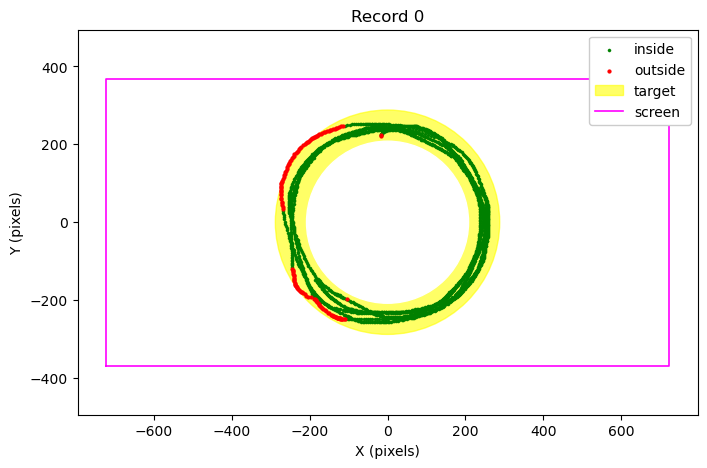

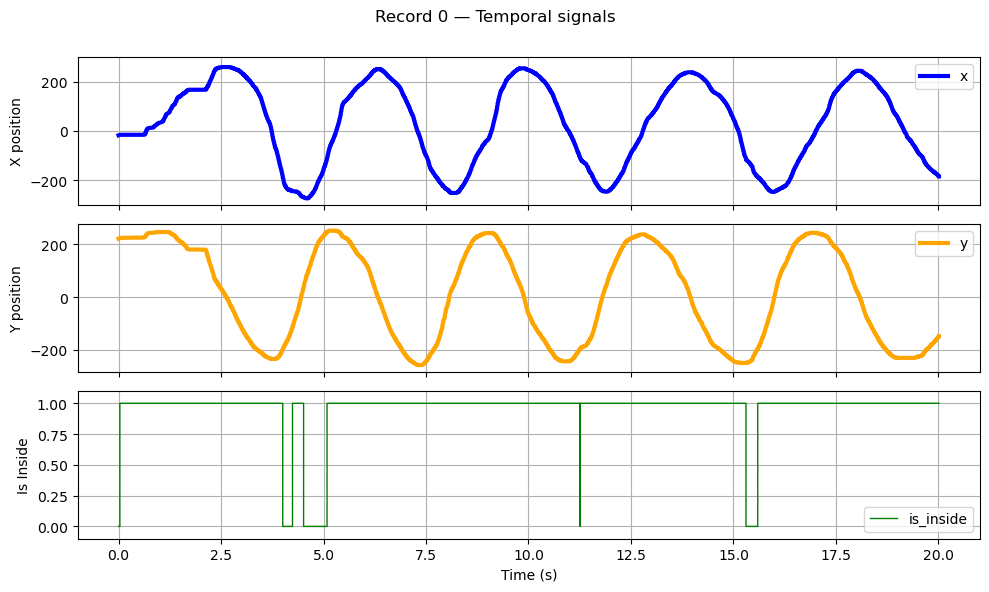

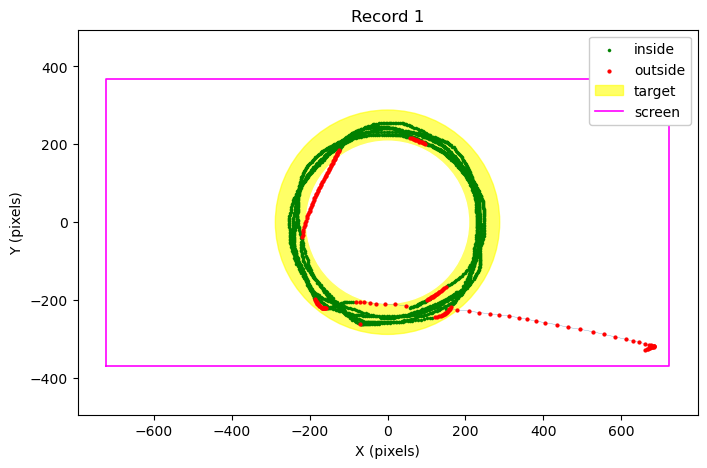

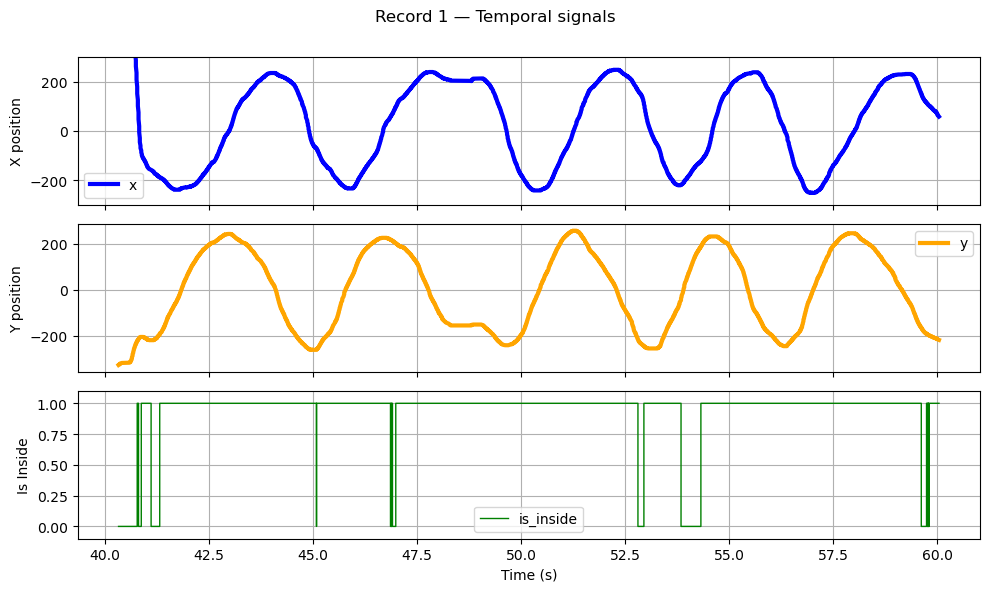

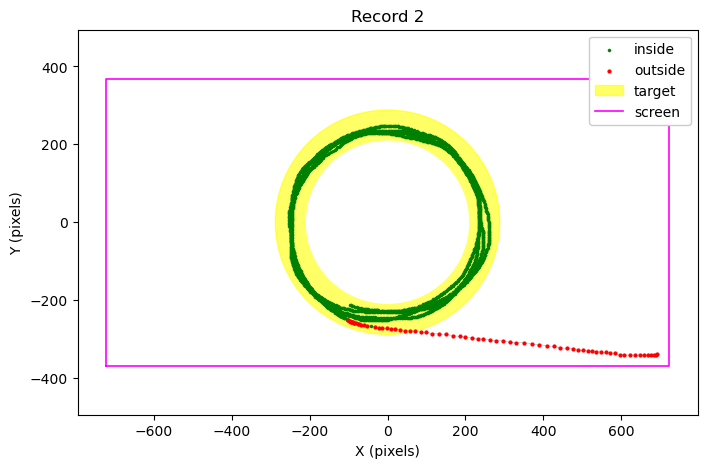

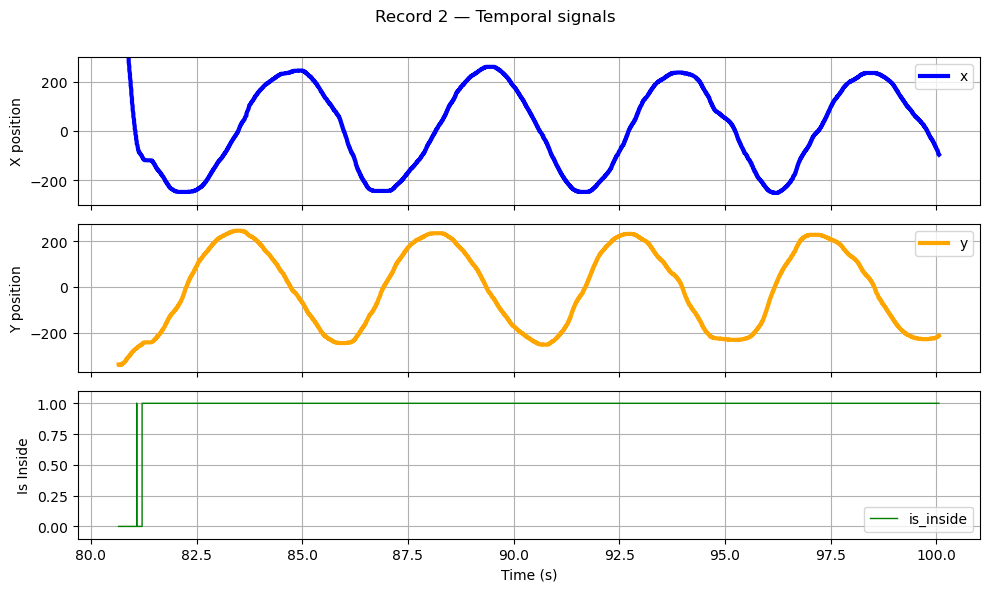

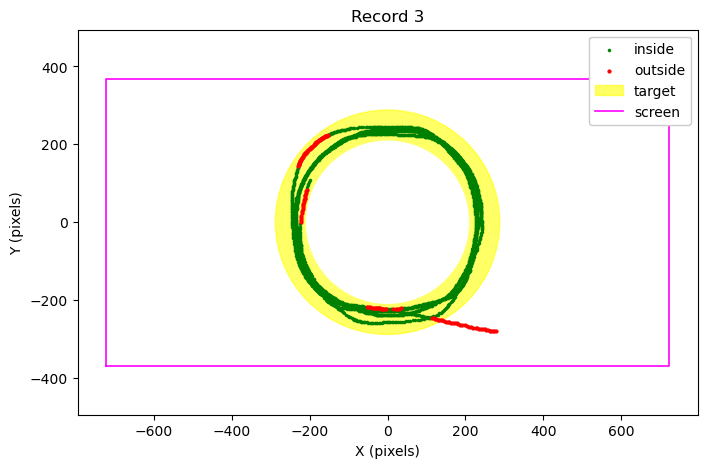

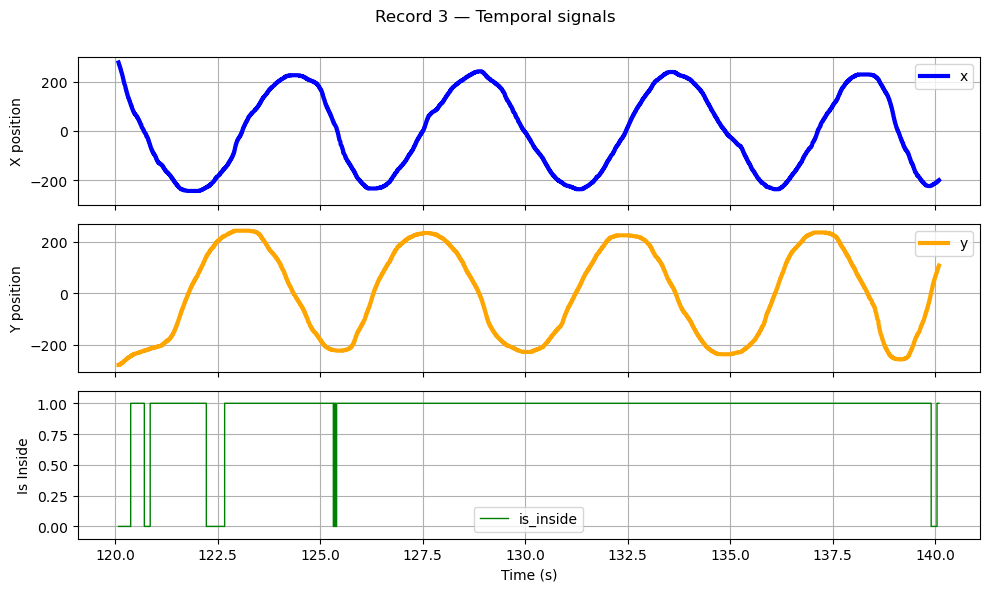

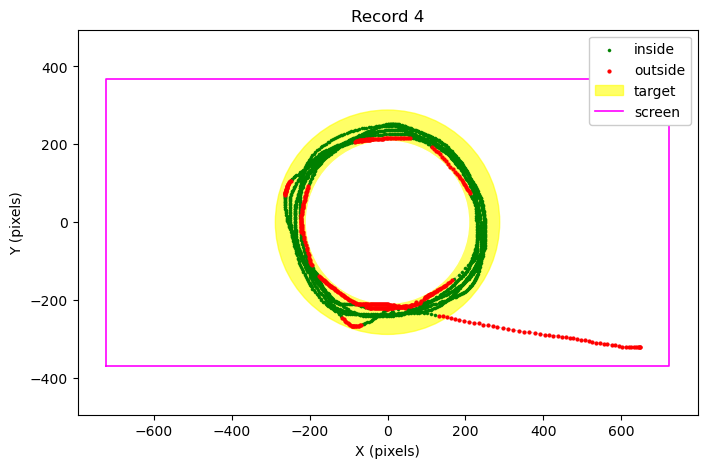

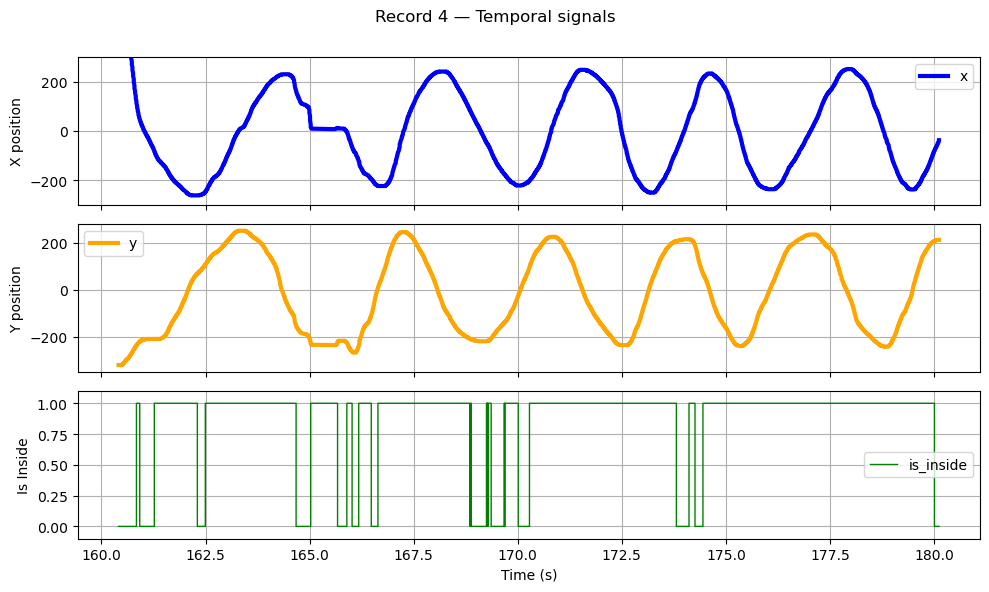

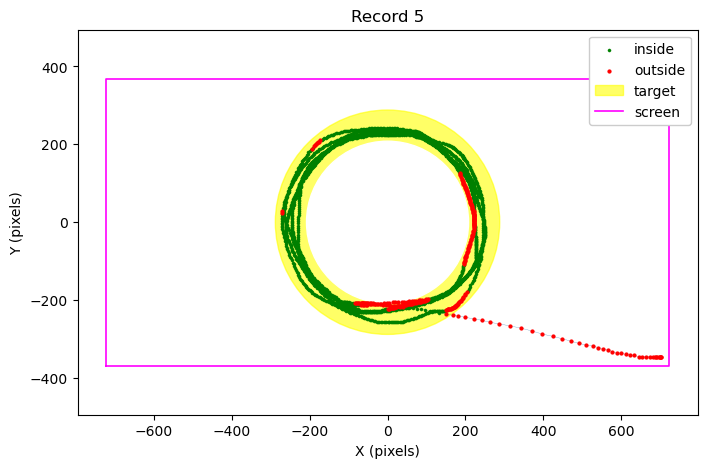

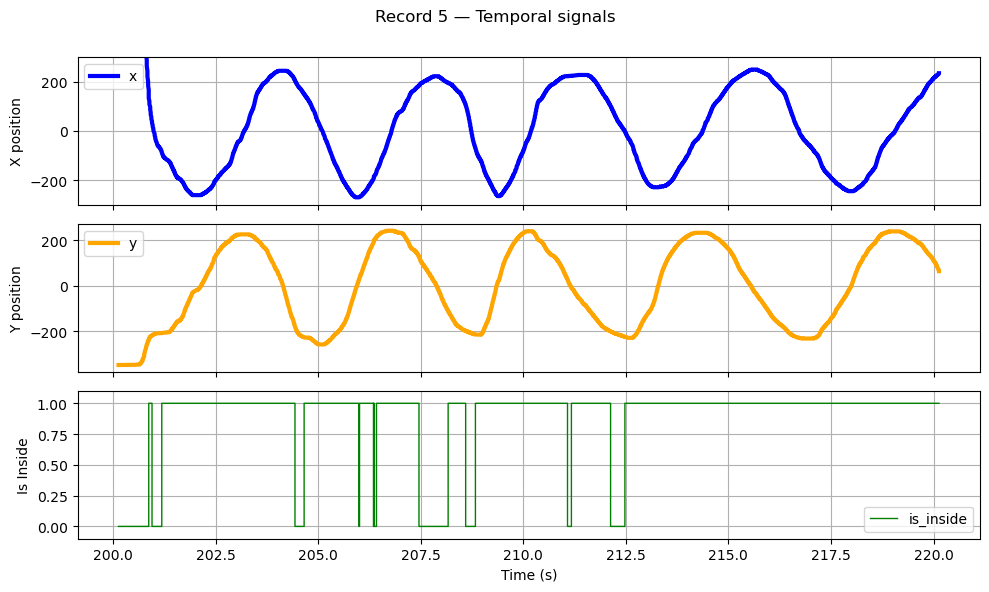

In [8]:
# Normalization of lengths to avoid error
m = min(len(time), len(mouseX), len(mouseY), len(in_target))
time = time[:m]
mouseX = mouseX[:m]
mouseY = mouseY[:m]
in_target = in_target[:m]

# Principal loop over records
records_data = []

for i, (start, end) in enumerate(zip(record_start_sec, record_end_sec), start=0):
    mask = (time >= start) & (time <= end)
    x_task = mouseX[mask] - centerX
    y_task = -(mouseY[mask] - centerY)
    t_task = time[mask]
    in_task = in_target[mask]

    records_data.append({
        "record": i,
        "time": t_task,
        "x": x_task,
        "y": y_task,
        "in_target": in_task
    })

    # ======================================================
    # Spatial plot (trajectory + target)
    # ======================================================
    fig1, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(x_task, y_task, '-', color='steelblue', label=None, zorder=2, lw=0.2)
    ax1.scatter(x_task[in_task == 1], y_task[in_task == 1],
                color='green', s=5, label='inside', zorder=3, lw=0.3)
    ax1.scatter(x_task[in_task == 0], y_task[in_task == 0],
                color='red', s=5, label='outside', zorder=3, lw=0.8)

    # Target (ring)
    circle_outer = plt.Circle((0, 0), externalRadius, color='yellow', alpha=0.6, zorder=1, label='target')
    circle_inner = plt.Circle((0, 0), internalRadius, color='white', zorder=2)
    ax1.add_patch(circle_outer)
    ax1.add_patch(circle_inner)

    # Screen border
    ax1.plot([-screenWidth/2, screenWidth/2, screenWidth/2, -screenWidth/2, -screenWidth/2],
             [-screenHeight/2, -screenHeight/2, screenHeight/2, screenHeight/2, -screenHeight/2],
             color='magenta', lw=1.2, label='screen', zorder=0)

    ax1.set_title(f"Record {i}")
    ax1.set_xlabel("X (pixels)")
    ax1.set_ylabel("Y (pixels)")
    ax1.axis("equal")
   # ax1.set_xlim(-600, 600)
    #ax1.set_ylim(-400, 400)
    ax1.legend(loc='upper right', framealpha=1, facecolor='white')
    ax1.grid(False)
    plt.show()

    # ======================================================
    # Temporal plot (X, Y, Inside)
    # ======================================================
    fig2, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    fig2.suptitle(f"Record {i} — Temporal signals")

    # X
    axes[0].plot(t_task, x_task, color='blue', label='x', lw=3)
    axes[0].set_ylabel("X position")
    axes[0].set_ylim(-300, 300)
    axes[0].legend()
    axes[0].grid(True)

    # Y
    axes[1].plot(t_task, y_task, color='orange', label='y', lw=3)
    axes[1].set_ylabel("Y position")
    axes[0].set_ylim(-300, 300)
    axes[1].legend()
    axes[1].grid(True)

    # Inside
    axes[2].step(t_task, in_task, where='post', color='green', label='is_inside', lw=1)
    axes[2].set_ylabel("Is Inside")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylim(-0.1, 1.1)
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()


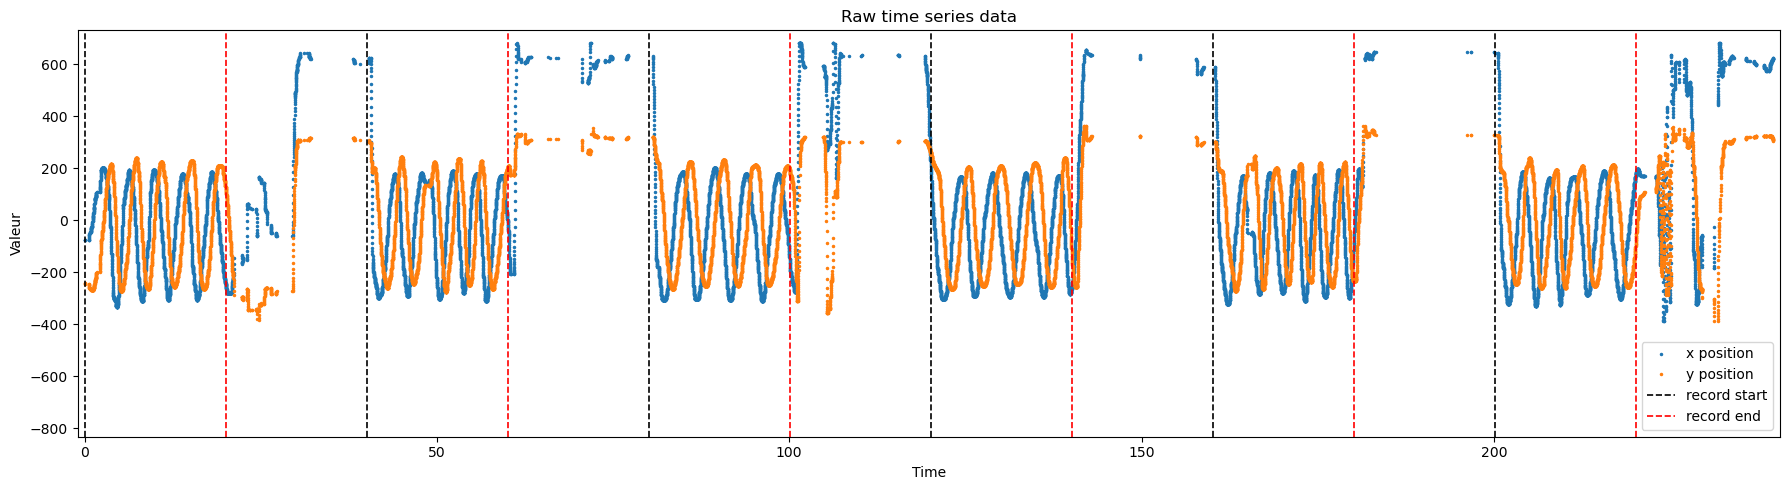

In [9]:
# --- Création des 5 graphes ---
plt.figure(figsize=(18, 5))

# --- Tracé des positions centrées (points pour lisibilité fine) ---
plt.plot(time, mouseX - np.mean(mouseX), '.', ms=3, color='tab:blue', label='x position')
plt.plot(time, mouseY - np.mean(mouseY), '.', ms=3, color='tab:orange', label='y position')

# --- Marqueurs de début et fin d’enregistrement ---
for s in record_start_sec:
    plt.axvline(s, color='black', linestyle='--', linewidth=1.2, label='record start' if s == record_start_sec[0] else "")
for e in record_end_sec:
    plt.axvline(e, color='red', linestyle='--', linewidth=1.2, label='record end' if e == record_end_sec[0] else "")

# --- Ajustements visuels ---
plt.xlim(min(time[0], record_start_sec[0]) - 1, max(time[-1], record_end_sec[-1]) + 1)
plt.ylim(np.min([mouseX - np.mean(mouseX), mouseY - np.mean(mouseY)]) - 50, np.max([mouseX - np.mean(mouseX), mouseY - np.mean(mouseY)]) + 50)

plt.xlabel("Time")
plt.ylabel("Valeur")
plt.title("Raw time series data")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()